

# Entrenamiento y Optimización de hiperparametros

Elegimos los siguientes modelos:
- KNN (Basado en distancia)
- Decision Tree (Arbol simple)
- Random Forest (Ensamble bagging)
- XGBoost (Ensamble Boosting)

Contexto **médico** (predicción de stroke) con clases altamente desbalanceadas (~19.5:1). Un **falso negativo** (no detectar un stroke) es mucho más costoso que un falso positivo.

Usamos **F-beta score** (β=3): Recall pesa ~9× más que Precision, pero a diferencia del recall puro sigue penalizando modelos degenerados que predicen todo positivo.

Para ajustar el peso de Recall, cambiar `BETA` en la celda de setup (actualmente 3).

In [90]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    make_scorer, fbeta_score,
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

import warnings
warnings.filterwarnings('ignore')

# El nb01 genera 3 splits: train / test / val.
#  - X_train: CV 5-fold para tuning de hiperparámetros.
#  - X_test:  comparación de los 4 modelos tuneados para elegir al ganador.
#  - X_val:   evaluación final del modelo ganador (holdout intocado).
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_test  = data['X_test']
X_val   = data['X_val']
y_train = data['y_train']
y_test  = data['y_test']
y_val   = data['y_val']

print(f'X_train: {X_train.shape} | X_test: {X_test.shape} | X_val: {X_val.shape}')
print(f'Distribución de clases (train): {np.bincount(y_train.astype(int))}')
print(f'Ratio de desbalance: {np.sum(y_train==0)/np.sum(y_train==1):.1f}:1')


X_train: (3065, 14) | X_test: (1022, 14) | X_val: (1022, 14)
Distribución de clases (train): [2916  149]
Ratio de desbalance: 19.6:1


## Setup compartido

Una sola vez: el scorer F-beta, la CV estratificada 5-fold, `scale_pos_weight` para XGBoost, y un helper `cv_f2` que evalúa un modelo con CV=5 y devuelve el F-beta medio (lo que cada `objective` de Optuna maximiza).

**Por qué Optuna y no RandomizedSearchCV:** Optuna con `TPESampler` (Tree-structured Parzen Estimator) hace búsqueda bayesiana — aprende de los trials previos y converge más rápido que random search, especialmente en espacios con parámetros continuos (`learning_rate`, `subsample`, `colsample_bytree`).

In [91]:
BETA = 3  # cambiar a 2 o 4 para ajustar el peso relativo de Recall vs Precision
METRIC_NAME = f'F{BETA}'  # se usa como clave de métricas en dicts/tablas
f2_scorer = make_scorer(fbeta_score, beta=BETA)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight para XGBoost (equivalente a class_weight='balanced' en sklearn)
neg, pos = np.bincount(y_train)
scale_pos = neg / pos

# Dict de métricas para reporting en la tabla comparativa (no para el optimizer)
scoring = {
    METRIC_NAME: f2_scorer,
    'Recall':    'recall',
    'Precision': 'precision',
    'ROC_AUC':   'roc_auc',
    'PR_AUC':    'average_precision',
}

# Silenciar logs verbosos de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Helper: evalúa un modelo con CV=5 y devuelve F-beta medio (lo que cada objective maximiza)
def cv_f2(model, X, y):
    return cross_val_score(model, X, y, cv=cv, scoring=f2_scorer, n_jobs=-1).mean()

## Decision Tree

Espacio de búsqueda: profundidad, criterio de split y regularización (`min_samples_*`). Se usa `class_weight='balanced'` para el desbalance.

In [92]:
def dt_objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    model = DecisionTreeClassifier(class_weight='balanced', random_state=42, **params)
    return cv_f2(model, X_train, y_train)

dt_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
dt_study.optimize(dt_objective, n_trials=50, show_progress_bar=True)

dt_best_params = dt_study.best_params
dt_best = DecisionTreeClassifier(
    class_weight='balanced', random_state=42, **dt_best_params
).fit(X_train, y_train)

print('Mejores parámetros (Decision Tree):')
for k, v in dt_best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor F2 en CV: {dt_study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (Decision Tree):
  max_depth: 3
  min_samples_leaf: 28
  min_samples_split: 7
  criterion: entropy

Mejor F2 en CV: 0.5382


## Random Forest

Espacio de búsqueda: número de árboles, profundidad, regularización y muestreo de features. Se usa `class_weight='balanced'`.

In [93]:
def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
        'max_depth':        trial.suggest_categorical('max_depth', [5, 10, 15, 20, None]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    }
    model = RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1, **params
    )
    return cv_f2(model, X_train, y_train)

rf_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

rf_best_params = rf_study.best_params
rf_best = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1, **rf_best_params
).fit(X_train, y_train)

print('Mejores parámetros (Random Forest):')
for k, v in rf_best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor F2 en CV: {rf_study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (Random Forest):
  n_estimators: 500
  max_depth: 5
  min_samples_leaf: 13
  max_features: 0.5

Mejor F2 en CV: 0.5445


## XGBoost

Espacio de búsqueda más rico: learning rate, subsampling de filas y columnas, `min_child_weight`. Se usa `scale_pos_weight` (equivalente a `class_weight='balanced'`).

In [94]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False,
        n_jobs=1,
        **params,
    )
    return cv_f2(model, X_train, y_train)

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

xgb_best_params = xgb_study.best_params
xgb_best = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
    n_jobs=1,
    **xgb_best_params,
).fit(X_train, y_train)

print('Mejores parámetros (XGBoost):')
for k, v in xgb_best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor F2 en CV: {xgb_study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (XGBoost):
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.015440955150091865
  min_child_weight: 7
  subsample: 0.6436983206372936
  colsample_bytree: 0.691976903707248

Mejor F2 en CV: 0.5442


## KNN

Espacio de búsqueda: número de vecinos, tipo de peso y métrica (`p=1` Manhattan, `p=2` Euclidiana). KNN no soporta `class_weight`, así que el desbalance no se corrige — se incluye como referencia.

In [95]:
def knn_objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p':           trial.suggest_categorical('p', [1, 2]),
    }
    model = KNeighborsClassifier(n_jobs=-1, **params)
    return cv_f2(model, X_train, y_train)

knn_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
knn_study.optimize(knn_objective, n_trials=50, show_progress_bar=True)

knn_best_params = knn_study.best_params
knn_best = KNeighborsClassifier(n_jobs=-1, **knn_best_params).fit(X_train, y_train)

print('Mejores parámetros (KNN):')
for k, v in knn_best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor F2 en CV: {knn_study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (KNN):
  n_neighbors: 4
  weights: distance
  p: 2

Mejor F2 en CV: 0.0646


## SVC

Espacio de búsqueda con 4 kernels (linear/rbf/poly/sigmoid). Se usa `class_weight='balanced'` y `probability=True` para poder calcular AUC-ROC y PR-AUC. El parámetro `C` y `gamma` dependen del kernel (espacios condicionales).

**Nota:** SVC con `probability=True` es más costoso que los otros modelos porque hace CV interno para calibrar probabilidades — este tuning tarda más.


In [96]:
def svc_objective(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])

    if kernel == 'linear':
        params = {
            'kernel': kernel,
            'C': trial.suggest_float('C_linear', 1e-3, 1e2, log=True),
        }
    elif kernel == 'rbf':
        params = {
            'kernel': kernel,
            'C':     trial.suggest_float('C_rbf', 1e-2, 1e2, log=True),
            'gamma': trial.suggest_categorical('gamma_rbf',
                ['scale', 'auto', 0.001, 0.005, 0.01, 0.05, 0.1]),
        }
    elif kernel == 'poly':
        params = {
            'kernel': kernel,
            'C':      trial.suggest_categorical('C_poly', [0.1, 1.0, 10.0]),
            'degree': trial.suggest_int('degree', 2, 4),
            'gamma':  trial.suggest_categorical('gamma_poly', ['scale', 'auto']),
        }
    else:  # sigmoid
        params = {
            'kernel': kernel,
            'C':     trial.suggest_categorical('C_sig', [0.1, 1.0, 10.0]),
            'gamma': trial.suggest_categorical('gamma_sig', ['scale', 'auto']),
        }

    model = SVC(
        class_weight='balanced',
        probability=True,
        random_state=42,
        **params,
    )
    return cv_f2(model, X_train, y_train)


def build_svc_from_params(best_params):
    kernel = best_params['kernel']
    build = dict(kernel=kernel, class_weight='balanced', probability=True, random_state=42)
    if kernel == 'linear':
        build['C'] = best_params['C_linear']
    elif kernel == 'rbf':
        build['C']     = best_params['C_rbf']
        build['gamma'] = best_params['gamma_rbf']
    elif kernel == 'poly':
        build['C']      = best_params['C_poly']
        build['degree'] = best_params['degree']
        build['gamma']  = best_params['gamma_poly']
    else:  # sigmoid
        build['C']     = best_params['C_sig']
        build['gamma'] = best_params['gamma_sig']
    return SVC(**build)


svc_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
svc_study.optimize(svc_objective, n_trials=50, show_progress_bar=True)

svc_best_params = svc_study.best_params
svc_best = build_svc_from_params(svc_best_params).fit(X_train, y_train)

print('Mejores parámetros (SVC):')
for k, v in svc_best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor F2 en CV: {svc_study.best_value:.4f}')


  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (SVC):
  kernel: rbf
  C_rbf: 0.8152728131129285
  gamma_rbf: 0.01

Mejor F2 en CV: 0.5491


## Resumen de Cross-Validation

Tabla con las métricas CV de la mejor configuración de cada modelo. La columna F-beta (F3 con BETA=3) es la que se usó para seleccionar.

In [97]:
def cv_row(name, model):
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'Modelo':    name,
        METRIC_NAME: scores[f'test_{METRIC_NAME}'].mean(),
        'Recall':    scores['test_Recall'].mean(),
        'Precision': scores['test_Precision'].mean(),
        'ROC-AUC':   scores['test_ROC_AUC'].mean(),
        'PR-AUC':    scores['test_PR_AUC'].mean(),
    }

cv_summary = (
    pd.DataFrame([
        cv_row('Decision Tree', dt_best),
        cv_row('Random Forest', rf_best),
        cv_row('XGBoost',       xgb_best),
        cv_row('KNN',           knn_best),
        cv_row('SVC',           svc_best),
    ])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(cv_summary.style.highlight_max(axis=0).format('{:.4f}'))

,F3,Recall,Precision,ROC-AUC,PR-AUC
Modelo,,,,,
SVC,0.5491,0.8591,0.1293,0.8498,0.2146
Random Forest,0.5445,0.7993,0.1410,0.8462,0.1853
XGBoost,0.5442,0.8062,0.1388,0.8439,0.1827
Decision Tree,0.5382,0.8995,0.1175,0.8255,0.1403
KNN,0.0646,0.0602,0.2093,0.6478,0.1187


## Comparación en Test Set (selección de modelo)

Cada `*_best` ya está reentrenado sobre todo `X_train`. Calculamos las métricas sobre `X_test` para comparar los 4 modelos tuneados y elegir al ganador. **`X_val` se reserva intocado** para la evaluación final del ganador.


In [98]:
# Decision Tree
y_prob_dt_test = dt_best.predict_proba(X_test)[:, 1]
y_pred_dt_test = dt_best.predict(X_test)

dt_metrics = {
    'Modelo':    'Decision Tree',
    'AUC-ROC':   roc_auc_score(y_test, y_prob_dt_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_dt_test),
    'F1':        f1_score(y_test, y_pred_dt_test),
    METRIC_NAME: fbeta_score(y_test, y_pred_dt_test, beta=BETA),
    'Recall':    recall_score(y_test, y_pred_dt_test),
    'Precision': precision_score(y_test, y_pred_dt_test, zero_division=0),
}
print(dt_metrics)


{'Modelo': 'Decision Tree', 'AUC-ROC': 0.834022633744856, 'PR-AUC': 0.17161044098946837, 'F1': 0.19383259911894274, 'F3': 0.5152224824355972, 'Recall': 0.88, 'Precision': 0.10891089108910891}


In [99]:
# Random Forest
y_prob_rf_test = rf_best.predict_proba(X_test)[:, 1]
y_pred_rf_test = rf_best.predict(X_test)

rf_metrics = {
    'Modelo':    'Random Forest',
    'AUC-ROC':   roc_auc_score(y_test, y_prob_rf_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_rf_test),
    'F1':        f1_score(y_test, y_pred_rf_test),
    METRIC_NAME: fbeta_score(y_test, y_pred_rf_test, beta=BETA),
    'Recall':    recall_score(y_test, y_pred_rf_test),
    'Precision': precision_score(y_test, y_pred_rf_test, zero_division=0),
}
print(rf_metrics)


{'Modelo': 'Random Forest', 'AUC-ROC': 0.8353703703703704, 'PR-AUC': 0.2171377192062716, 'F1': 0.22099447513812154, 'F3': 0.5249343832020997, 'Recall': 0.8, 'Precision': 0.1282051282051282}


In [100]:
# XGBoost
y_prob_xgb_test = xgb_best.predict_proba(X_test)[:, 1]
y_pred_xgb_test = xgb_best.predict(X_test)

xgb_metrics = {
    'Modelo':    'XGBoost',
    'AUC-ROC':   roc_auc_score(y_test, y_prob_xgb_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_xgb_test),
    'F1':        f1_score(y_test, y_pred_xgb_test),
    METRIC_NAME: fbeta_score(y_test, y_pred_xgb_test, beta=BETA),
    'Recall':    recall_score(y_test, y_pred_xgb_test),
    'Precision': precision_score(y_test, y_pred_xgb_test, zero_division=0),
}
print(xgb_metrics)


{'Modelo': 'XGBoost', 'AUC-ROC': 0.8314609053497942, 'PR-AUC': 0.21454890628117804, 'F1': 0.20911528150134048, 'F3': 0.5045278137128072, 'Recall': 0.78, 'Precision': 0.12074303405572756}


In [101]:
# KNN
y_prob_knn_test = knn_best.predict_proba(X_test)[:, 1]
y_pred_knn_test = knn_best.predict(X_test)

knn_metrics = {
    'Modelo':    'KNN',
    'AUC-ROC':   roc_auc_score(y_test, y_prob_knn_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_knn_test),
    'F1':        f1_score(y_test, y_pred_knn_test),
    METRIC_NAME: fbeta_score(y_test, y_pred_knn_test, beta=BETA),
    'Recall':    recall_score(y_test, y_pred_knn_test),
    'Precision': precision_score(y_test, y_pred_knn_test, zero_division=0),
}
print(knn_metrics)


{'Modelo': 'KNN', 'AUC-ROC': 0.5628806584362139, 'PR-AUC': 0.06188878936941127, 'F1': 0.05714285714285714, 'F3': 0.0425531914893617, 'Recall': 0.04, 'Precision': 0.1}


In [102]:
# SVC
y_prob_svc_test = svc_best.predict_proba(X_test)[:, 1]
y_pred_svc_test = svc_best.predict(X_test)

svc_metrics = {
    'Modelo':    'SVC',
    'AUC-ROC':   roc_auc_score(y_test, y_prob_svc_test),
    'PR-AUC':    average_precision_score(y_test, y_prob_svc_test),
    'F1':        f1_score(y_test, y_pred_svc_test),
    METRIC_NAME: fbeta_score(y_test, y_pred_svc_test, beta=BETA),
    'Recall':    recall_score(y_test, y_pred_svc_test),
    'Precision': precision_score(y_test, y_pred_svc_test, zero_division=0),
}
print(svc_metrics)


{'Modelo': 'SVC', 'AUC-ROC': 0.8380041152263374, 'PR-AUC': 0.20626882624375878, 'F1': 0.20707070707070707, 'F3': 0.5150753768844221, 'Recall': 0.82, 'Precision': 0.11849710982658959}


In [103]:
test_df = (
    pd.DataFrame([dt_metrics, rf_metrics, xgb_metrics, knn_metrics, svc_metrics])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(test_df.style.highlight_max(axis=0).format('{:.4f}'))

best_model_name = test_df[METRIC_NAME].idxmax()
print(f'\nMejor modelo por {METRIC_NAME} en test: {best_model_name} '
      f'({METRIC_NAME}={test_df.loc[best_model_name, METRIC_NAME]:.4f}, '
      f'Recall={test_df.loc[best_model_name, "Recall"]:.4f})')


,AUC-ROC,PR-AUC,F1,F3,Recall,Precision
Modelo,,,,,,
Random Forest,0.8354,0.2171,0.2210,0.5249,0.8000,0.1282
Decision Tree,0.8340,0.1716,0.1938,0.5152,0.8800,0.1089
SVC,0.8380,0.2063,0.2071,0.5151,0.8200,0.1185
XGBoost,0.8315,0.2145,0.2091,0.5045,0.7800,0.1207
KNN,0.5629,0.0619,0.0571,0.0426,0.0400,0.1000



Mejor modelo por F3 en test: Random Forest (F3=0.5249, Recall=0.8000)


## Curvas ROC y Precision-Recall (Test Set)


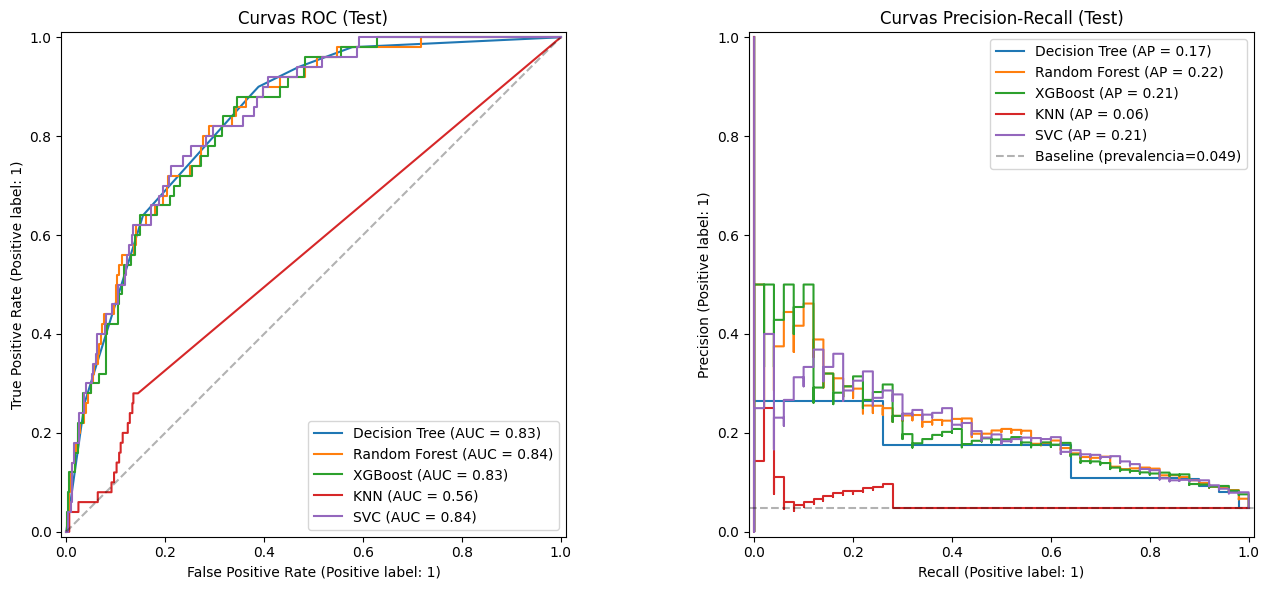

In [104]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
RocCurveDisplay.from_predictions(y_test, y_prob_dt_test,  name='Decision Tree', ax=ax_roc)
RocCurveDisplay.from_predictions(y_test, y_prob_rf_test,  name='Random Forest', ax=ax_roc)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb_test, name='XGBoost',       ax=ax_roc)
RocCurveDisplay.from_predictions(y_test, y_prob_knn_test, name='KNN',           ax=ax_roc)
RocCurveDisplay.from_predictions(y_test, y_prob_svc_test, name='SVC',           ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set_title('Curvas ROC (Test)')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_prob_dt_test,  name='Decision Tree', ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf_test,  name='Random Forest', ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb_test, name='XGBoost',       ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_knn_test, name='KNN',           ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_svc_test, name='SVC',           ax=ax_pr)
prevalence = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
ax_pr.axhline(prevalence, color='k', linestyle='--', alpha=0.3,
              label=f'Baseline (prevalencia={prevalence:.3f})')
ax_pr.legend(loc='upper right')
ax_pr.set_title('Curvas Precision-Recall (Test)')

plt.tight_layout()
plt.show()


## Matrices de Confusión en Test Set (threshold=0.5)


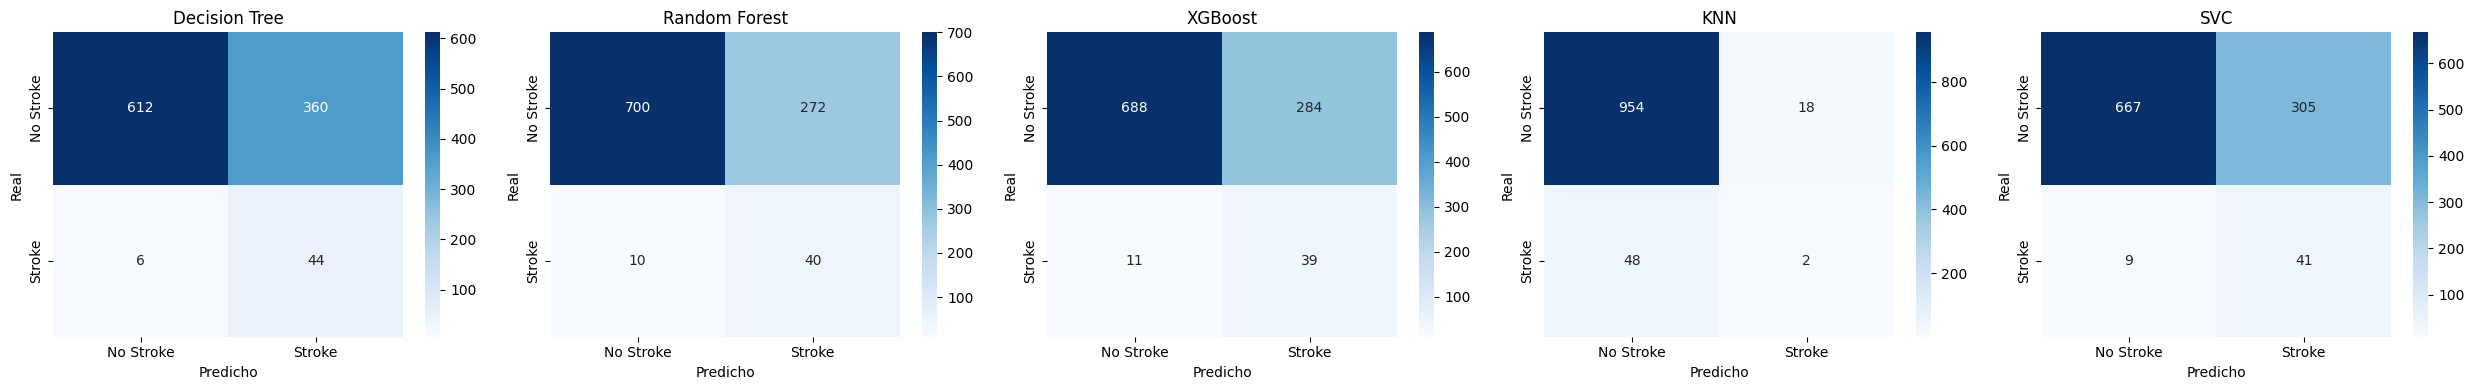

In [105]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
ax_dt, ax_rf, ax_xgb, ax_knn, ax_svc = axes

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_test)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax_dt,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
ax_dt.set_title('Decision Tree'); ax_dt.set_xlabel('Predicho'); ax_dt.set_ylabel('Real')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax_rf,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
ax_rf.set_title('Random Forest'); ax_rf.set_xlabel('Predicho'); ax_rf.set_ylabel('Real')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb_test)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax_xgb,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
ax_xgb.set_title('XGBoost'); ax_xgb.set_xlabel('Predicho'); ax_xgb.set_ylabel('Real')

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn_test)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=ax_knn,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
ax_knn.set_title('KNN'); ax_knn.set_xlabel('Predicho'); ax_knn.set_ylabel('Real')

# SVC
cm_svc = confusion_matrix(y_test, y_pred_svc_test)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', ax=ax_svc,
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
ax_svc.set_title('SVC'); ax_svc.set_xlabel('Predicho'); ax_svc.set_ylabel('Real')

plt.tight_layout()
plt.show()


## Evaluación final en Validation Set

`X_val` es el holdout intocado — no se usó ni para tuning (CV sobre `X_train`) ni para selección (comparación sobre `X_test`). Evaluamos **solo el modelo ganador** para obtener un estimado honesto del desempeño en datos nunca vistos.


In [106]:
# Recuperar el modelo ganador por nombre
best_models = {
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost':       xgb_best,
    'KNN':           knn_best,
    'SVC':           svc_best,
}
best_model = best_models[best_model_name]

y_prob_val = best_model.predict_proba(X_val)[:, 1]
y_pred_val = best_model.predict(X_val)

val_metrics = {
    'Modelo':    best_model_name,
    'AUC-ROC':   roc_auc_score(y_val, y_prob_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_val),
    'F1':        f1_score(y_val, y_pred_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_val),
    'Precision': precision_score(y_val, y_pred_val, zero_division=0),
}
val_df = pd.DataFrame([val_metrics]).set_index('Modelo')
display(val_df.style.format('{:.4f}'))

# Comparativa test vs val para detectar overfitting a test durante la selección
comparison = pd.DataFrame({
    'Test (selección)': test_df.loc[best_model_name],
    'Val (holdout final)': val_df.loc[best_model_name],
})
print('\nComparativa métricas del ganador en Test vs Val:')
display(comparison.style.format('{:.4f}'))

,AUC-ROC,PR-AUC,F1,F3,Recall,Precision
Modelo,,,,,,
Random Forest,0.8102,0.2491,0.2131,0.5091,0.7800,0.1234



Comparativa métricas del ganador en Test vs Val:


,Test (selección),Val (holdout final)
AUC-ROC,0.8354,0.8102
PR-AUC,0.2171,0.2491
F1,0.2210,0.2131
F3,0.5249,0.5091
Recall,0.8000,0.7800
Precision,0.1282,0.1234


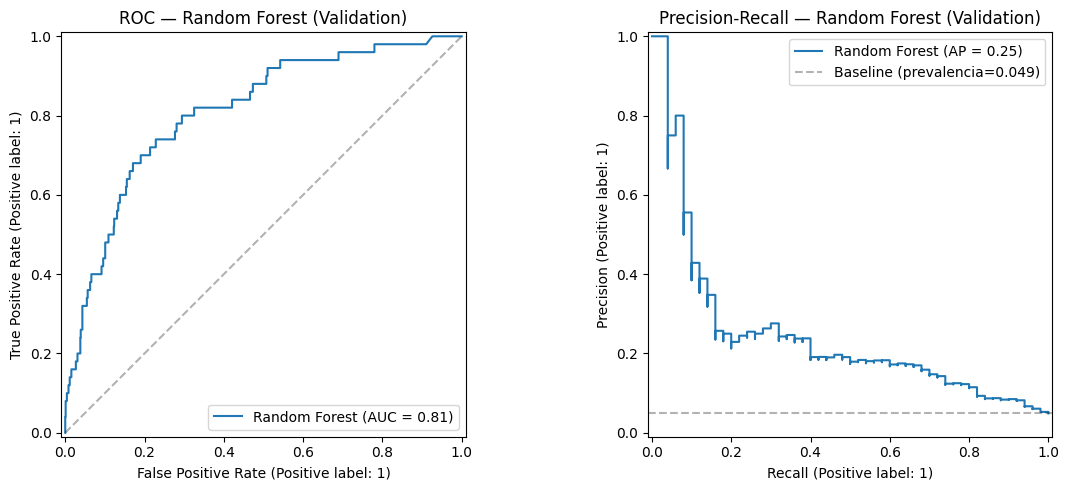

In [107]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_val, y_prob_val, name=best_model_name, ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set_title(f'ROC — {best_model_name} (Validation)')

PrecisionRecallDisplay.from_predictions(y_val, y_prob_val, name=best_model_name, ax=ax_pr)
prevalence_val = y_val.mean() if hasattr(y_val, 'mean') else np.mean(y_val)
ax_pr.axhline(prevalence_val, color='k', linestyle='--', alpha=0.3,
              label=f'Baseline (prevalencia={prevalence_val:.3f})')
ax_pr.legend(loc='upper right')
ax_pr.set_title(f'Precision-Recall — {best_model_name} (Validation)')

plt.tight_layout()
plt.show()


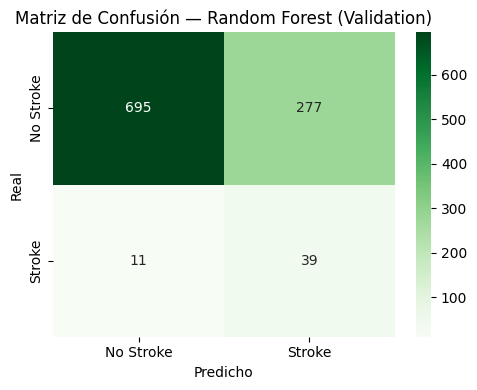

In [108]:
cm_val = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Matriz de Confusión — {best_model_name} (Validation)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout()
plt.show()


## Persistencia

Guardamos los 5 modelos tuneados y un `.pkl` con `best_params`, F-beta en CV, `test_results` (5 modelos sobre X_test) y `val_results` (ganador sobre X_val).

In [109]:
os.makedirs('../models', exist_ok=True)

joblib.dump(dt_best,  '../models/decision_tree_tuned.pkl')
joblib.dump(rf_best,  '../models/random_forest_tuned.pkl')
joblib.dump(xgb_best, '../models/xgboost_tuned.pkl')
joblib.dump(knn_best, '../models/knn_tuned.pkl')
joblib.dump(svc_best, '../models/svc_tuned.pkl')
print('Modelos guardados en ../models/*_tuned.pkl')

feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None

joblib.dump({
    'best_params': {
        'Decision Tree': dt_study.best_params,
        'Random Forest': rf_study.best_params,
        'XGBoost':       xgb_study.best_params,
        'KNN':           knn_study.best_params,
        'SVC':           svc_study.best_params,
    },
    'cv_best_fbeta': {
        'Decision Tree': dt_study.best_value,
        'Random Forest': rf_study.best_value,
        'XGBoost':       xgb_study.best_value,
        'KNN':           knn_study.best_value,
        'SVC':           svc_study.best_value,
    },
    'beta':            BETA,
    'metric_name':     METRIC_NAME,
    'test_results':    test_df,   # 5 modelos comparados sobre X_test
    'val_results':     val_df,    # ganador evaluado sobre X_val (holdout final)
    'best_model_name': best_model_name,
    'feature_names':   feature_names,
}, '../data/tuning_results.pkl')

print(f'\nResumen guardado en ../data/tuning_results.pkl')
print(f'Mejor modelo por {METRIC_NAME} en test: {best_model_name} -> {METRIC_NAME}(test)={test_df.loc[best_model_name, METRIC_NAME]:.4f} | {METRIC_NAME}(val)={val_df.loc[best_model_name, METRIC_NAME]:.4f}')

Modelos guardados en ../models/*_tuned.pkl

Resumen guardado en ../data/tuning_results.pkl
Mejor modelo por F3 en test: Random Forest -> F3(test)=0.5249 | F3(val)=0.5091
